# Traffic Sign Detection Notebook

This notebook builds a classical computer vision traffic sign detector step by step.

It is designed for this project and uses the processed dataset in `data/processed`.

The goal is to make each stage easy to understand, visualize, and debug:

1. Load a processed image
2. Convert it to HSV
3. Segment red and blue colors
4. Clean the masks
5. Detect contours
6. Filter contours by size and shape
7. Reduce false positives such as sky
8. Extract ROIs
9. Show the final detections

In [28]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "detection":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}


def collect_processed_images():
    image_paths = []

    for folder_name in ["gaussian", "median"]:
        folder = PROCESSED_DIR / folder_name
        if folder.exists():
            image_paths.extend(
                sorted(path for path in folder.iterdir() if path.suffix.lower() in IMAGE_EXTENSIONS)
            )

    if not image_paths and PROCESSED_DIR.exists():
        image_paths.extend(
            sorted(path for path in PROCESSED_DIR.rglob("*") if path.suffix.lower() in IMAGE_EXTENSIONS)
        )

    return image_paths


def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def show_image(title, image, cmap=None, figsize=(6, 6)):
    plt.figure(figsize=figsize)
    if image.ndim == 3 and cmap is None:
        plt.imshow(bgr_to_rgb(image))
    else:
        plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_images(items, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    total = len(items)

    for index, (title, image, cmap) in enumerate(items, start=1):
        plt.subplot(1, total, index)
        if image.ndim == 3 and cmap is None:
            plt.imshow(bgr_to_rgb(image))
        else:
            plt.imshow(image, cmap=cmap)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


image_paths = collect_processed_images()
print(f"Processed directory: {PROCESSED_DIR}")
print(f"Images found: {len(image_paths)}")

if image_paths:
    print(f"First image: {image_paths[8].relative_to(PROJECT_ROOT)}")
else:
    print("No processed images were found. Run preprocessing first, then re-run this notebook.")

Processed directory: c:\Users\rhmar\GitHub\Traffic-Sign-Detection\data\processed
Images found: 1754
First image: data\processed\gaussian\road105.png


## Step 1: Load and Display an Image

We start with one image from the processed dataset.

Using processed images is helpful here because preprocessing has already reduced some noise, which makes color segmentation more stable.

If your processed folders are empty, run the preprocessing module first.

Loaded image: data\processed\gaussian\road147.png
Image shape: (224, 224, 3)


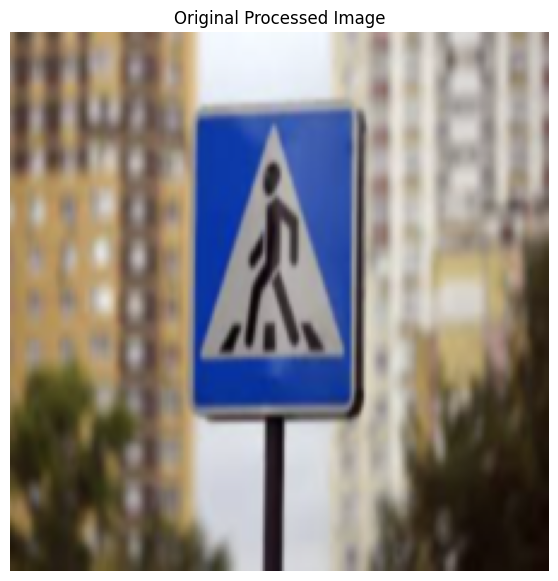

In [29]:
if not image_paths:
    raise FileNotFoundError(
        "No images were found inside data/processed. Run preprocessing first or add processed images."
    )

sample_index = 54
image_path = image_paths[sample_index]
image_bgr = cv2.imread(str(image_path))

if image_bgr is None:
    raise ValueError(f"Could not load image: {image_path}")

print(f"Loaded image: {image_path.relative_to(PROJECT_ROOT)}")
print(f"Image shape: {image_bgr.shape}")
show_image("Original Processed Image", image_bgr, figsize=(7, 7))

## Step 2: Convert the Image to HSV

HSV is usually better than BGR for color-based detection because it separates:

- `Hue`: the actual color type
- `Saturation`: how strong the color is
- `Value`: brightness

This makes it easier to define red and blue color ranges, even when lighting changes.

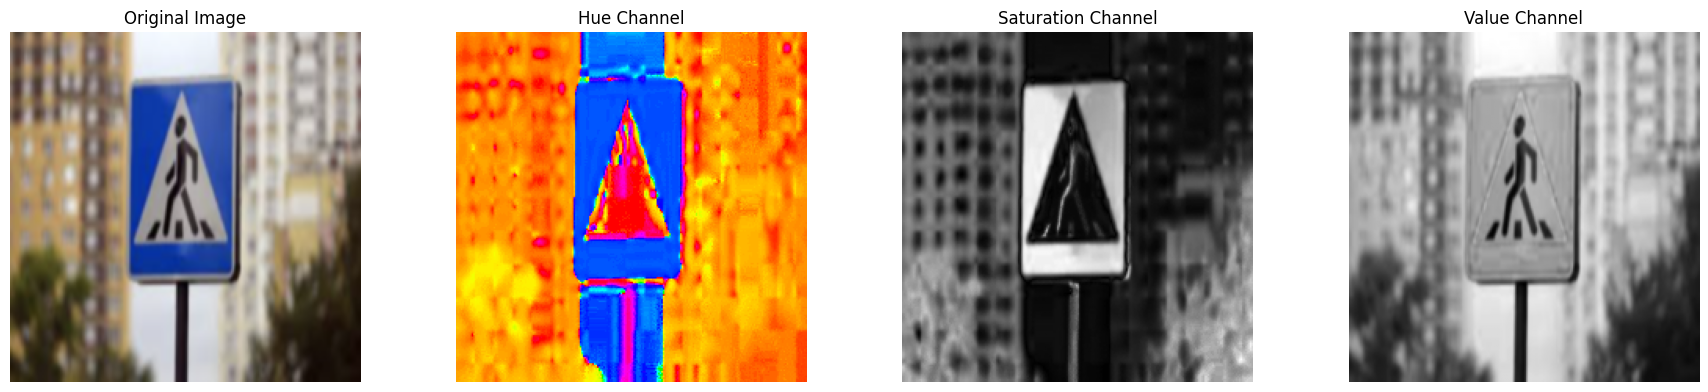

In [30]:
image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
h_channel, s_channel, v_channel = cv2.split(image_hsv)

show_images(
    [
        ("Original Image", image_bgr, None),
        ("Hue Channel", h_channel, "hsv"),
        ("Saturation Channel", s_channel, "gray"),
        ("Value Channel", v_channel, "gray"),
    ],
    figsize=(18, 4),
)

## Step 3: Color Segmentation for Red and Blue

Traffic signs in this project are mainly detected through color segmentation.

We use:

- two HSV ranges for red, because red wraps around the HSV hue scale
- one tighter HSV range for blue, to avoid detecting large sky regions

At this stage we only build raw masks with `cv2.inRange()`.

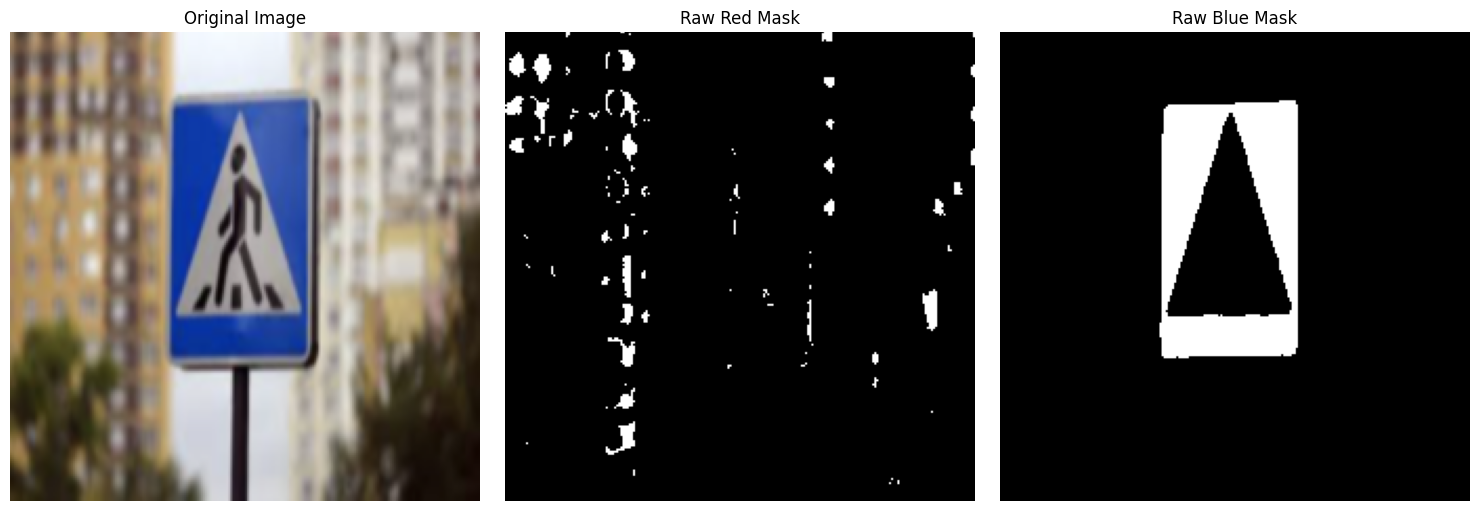

In [31]:
# Red is split into two ranges because hue wraps around in HSV.
lower_red_1 = np.array([0, 45, 40])
upper_red_1 = np.array([10, 255, 255])
lower_red_2 = np.array([170, 45, 40])
upper_red_2 = np.array([180, 255, 255])

# Blue is kept tighter to reduce sky detections.
lower_blue = np.array([100, 120, 50])
upper_blue = np.array([128, 255, 255])

raw_red_mask_1 = cv2.inRange(image_hsv, lower_red_1, upper_red_1)
raw_red_mask_2 = cv2.inRange(image_hsv, lower_red_2, upper_red_2)
raw_red_mask = cv2.bitwise_or(raw_red_mask_1, raw_red_mask_2)
raw_blue_mask = cv2.inRange(image_hsv, lower_blue, upper_blue)

show_images(
    [
        ("Original Image", image_bgr, None),
        ("Raw Red Mask", raw_red_mask, "gray"),
        ("Raw Blue Mask", raw_blue_mask, "gray"),
    ],
    figsize=(15, 5),
)

## Step 4: Clean the Masks with Morphology

Raw masks usually contain noise, gaps, and tiny unwanted regions.

We use:

- `Opening` to remove small noise
- `Closing` to connect nearby pixels

Blue uses slightly stronger cleaning because sky and background often introduce more false positives.

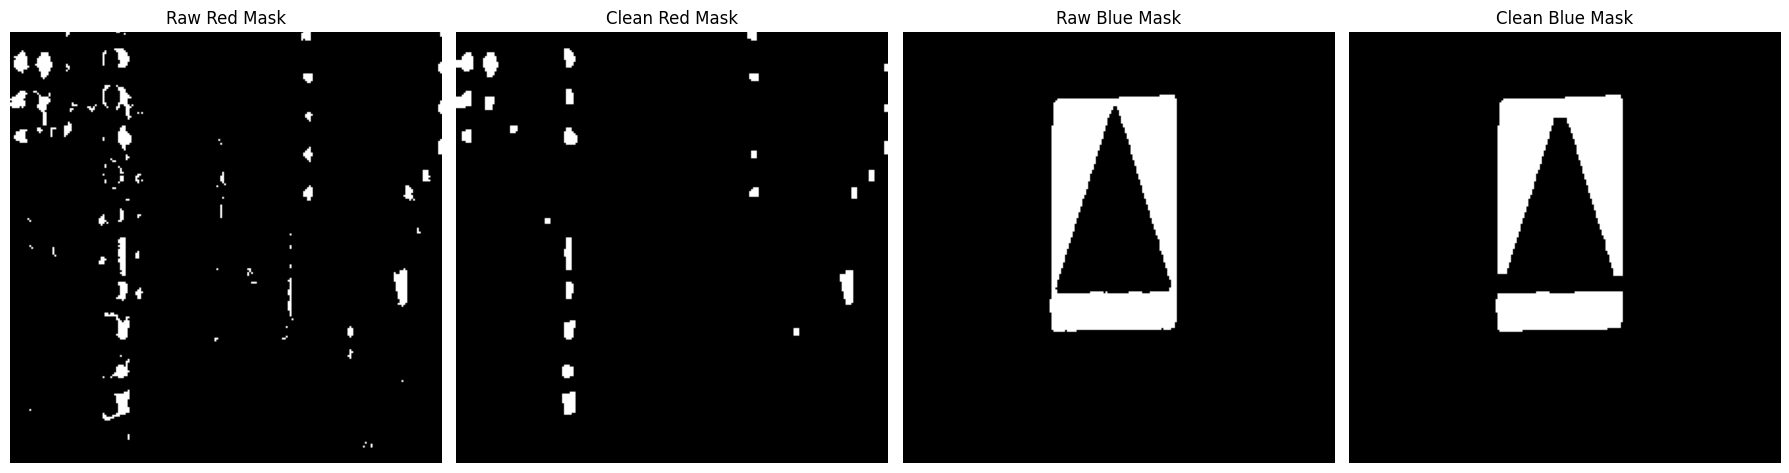

In [32]:
def clean_mask(mask, color_name):
    if color_name == "Blue":
        open_kernel = np.ones((5, 5), np.uint8)
        close_kernel = np.ones((7, 7), np.uint8)
    else:
        open_kernel = np.ones((3, 3), np.uint8)
        close_kernel = np.ones((5, 5), np.uint8)

    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, open_kernel)
    cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, close_kernel)
    return opened, cleaned


red_opened, clean_red_mask = clean_mask(raw_red_mask, "Red")
blue_opened, clean_blue_mask = clean_mask(raw_blue_mask, "Blue")

show_images(
    [
        ("Raw Red Mask", raw_red_mask, "gray"),
        ("Clean Red Mask", clean_red_mask, "gray"),
        ("Raw Blue Mask", raw_blue_mask, "gray"),
        ("Clean Blue Mask", clean_blue_mask, "gray"),
    ],
    figsize=(18, 5),
)

## Step 5: Detect Contours

Contours are the connected boundaries of each detected color region.

At this step we do not filter anything yet. We simply inspect where the red and blue masks produce candidate regions.

Red contours found: 26
Blue contours found: 2


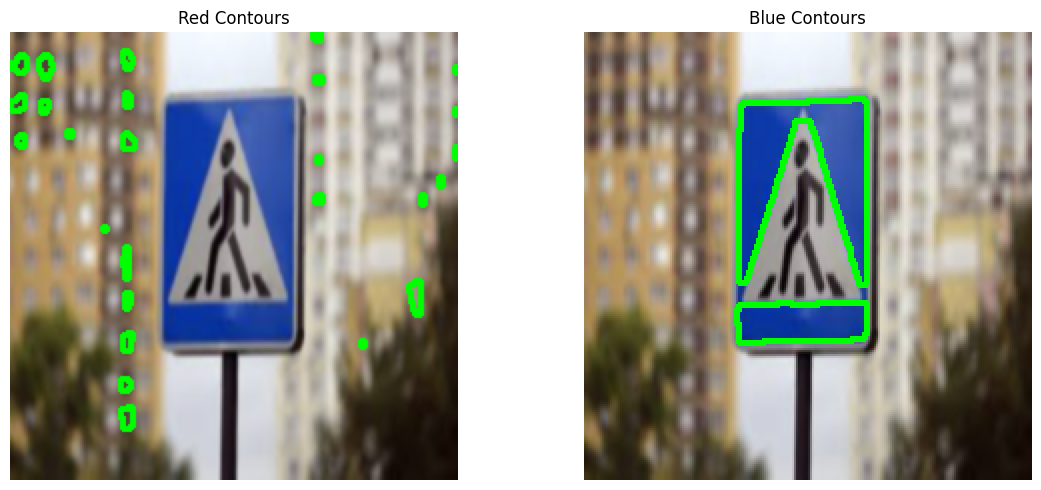

In [33]:
red_contours, _ = cv2.findContours(clean_red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
blue_contours, _ = cv2.findContours(clean_blue_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

red_contour_image = image_bgr.copy()
blue_contour_image = image_bgr.copy()

cv2.drawContours(red_contour_image, red_contours, -1, (0, 255, 0), 2)
cv2.drawContours(blue_contour_image, blue_contours, -1, (0, 255, 0), 2)

print(f"Red contours found: {len(red_contours)}")
print(f"Blue contours found: {len(blue_contours)}")

show_images(
    [
        ("Red Contours", red_contour_image, None),
        ("Blue Contours", blue_contour_image, None),
    ],
    figsize=(12, 5),
)

## Step 6 and 7: Filter Contours by Size, Shape, and Color Coverage

Not every contour is a traffic sign. We filter them using simple rules:

- `Minimum area`: removes tiny noisy regions
- `Maximum area`: removes very large regions such as sky or background
- `Aspect ratio`: traffic signs are usually close to square or circular
- `Fill ratio`: the contour should cover a meaningful part of its bounding box
- `Shape filtering`: with `cv2.approxPolyDP()` we keep triangles, rectangles, and circle-like shapes

We also reject large blue regions near the top of the image because that is where the sky usually appears.

Accepted red candidates: 0
Accepted blue candidates: 0
Green boxes are accepted. Purple boxes are rejected.


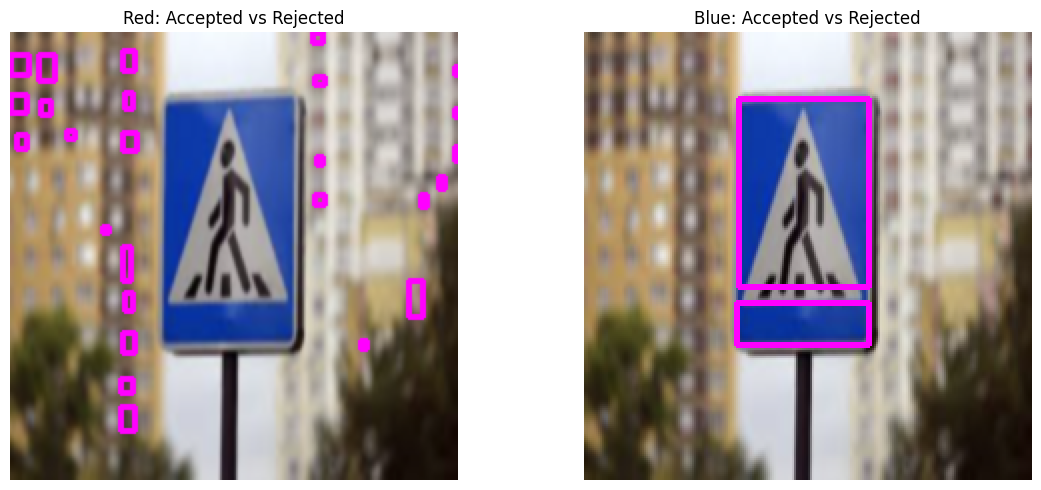

In [34]:
RED_SETTINGS = {
    "min_area": 70,
    "max_area_ratio": 0.12,
    "min_fill_ratio": 0.10,
    "min_color_ratio": 0.08,
}

BLUE_SETTINGS = {
    "min_area": 120,
    "max_area_ratio": 0.06,
    "min_fill_ratio": 0.25,
    "min_color_ratio": 0.30,
}


def classify_shape(contour):
    perimeter = cv2.arcLength(contour, True)
    if perimeter == 0:
        return "rejected", 0

    approx = cv2.approxPolyDP(contour, 0.04 * perimeter, True)
    sides = len(approx)

    if sides == 3:
        return "triangle", sides
    if sides == 4:
        return "rectangle", sides
    if sides >= 6:
        return "circle-like", sides

    return "rejected", sides


def touches_border(x, y, w, h, image_width, image_height, margin=5):
    return (
        x <= margin
        or y <= margin
        or (x + w) >= image_width - margin
        or (y + h) >= image_height - margin
    )


def contour_to_detection(contour, mask, image, color_name, settings):
    image_height, image_width = image.shape[:2]
    image_area = image_height * image_width
    area = cv2.contourArea(contour)

    if area < settings["min_area"] or area > settings["max_area_ratio"] * image_area:
        return None, "area"

    x, y, w, h = cv2.boundingRect(contour)
    if w < 12 or h < 12:
        return None, "size"

    if color_name == "Blue" and touches_border(x, y, w, h, image_width, image_height):
        return None, "border"

    if color_name == "Blue" and y < int(0.25 * image_height) and area > 0.01 * image_area:
        return None, "top sky"

    aspect_ratio = w / float(h)
    if color_name == "Blue":
        if not 0.60 <= aspect_ratio <= 1.40:
            return None, "aspect"
    else:
        if not 0.45 <= aspect_ratio <= 1.60:
            return None, "aspect"

    bbox_area = float(w * h)
    fill_ratio = area / bbox_area
    if fill_ratio < settings["min_fill_ratio"]:
        return None, "fill"

    roi_mask = mask[y : y + h, x : x + w]
    color_ratio = cv2.countNonZero(roi_mask) / bbox_area
    if color_ratio < settings["min_color_ratio"]:
        return None, "color"

    shape_name, shape_sides = classify_shape(contour)
    if shape_name == "rejected":
        return None, "shape"

    detection = {
        "color": color_name,
        "bbox": (x, y, w, h),
        "area": area,
        "fill_ratio": fill_ratio,
        "color_ratio": color_ratio,
        "shape_name": shape_name,
        "shape_sides": shape_sides,
        "score": area + 1000 * color_ratio + 200 * fill_ratio,
    }
    return detection, "accepted"


red_debug = image_bgr.copy()
blue_debug = image_bgr.copy()
accepted_red = []
accepted_blue = []

for contour in red_contours:
    detection, reason = contour_to_detection(contour, clean_red_mask, image_bgr, "Red", RED_SETTINGS)
    x, y, w, h = cv2.boundingRect(contour)
    color = (0, 255, 0) if detection is not None else (255, 0, 255)
    cv2.rectangle(red_debug, (x, y), (x + w, y + h), color, 2)
    if detection is not None:
        accepted_red.append(detection)

for contour in blue_contours:
    detection, reason = contour_to_detection(contour, clean_blue_mask, image_bgr, "Blue", BLUE_SETTINGS)
    x, y, w, h = cv2.boundingRect(contour)
    color = (0, 255, 0) if detection is not None else (255, 0, 255)
    cv2.rectangle(blue_debug, (x, y), (x + w, y + h), color, 2)
    if detection is not None:
        accepted_blue.append(detection)

print(f"Accepted red candidates: {len(accepted_red)}")
print(f"Accepted blue candidates: {len(accepted_blue)}")
print("Green boxes are accepted. Purple boxes are rejected.")

show_images(
    [
        ("Red: Accepted vs Rejected", red_debug, None),
        ("Blue: Accepted vs Rejected", blue_debug, None),
    ],
    figsize=(12, 5),
)

## Step 8, 9, and 10: Extract ROIs, Reduce False Positives, and Build the Final Result

Now we combine everything into one detection function.

This final step:

- builds red and blue masks
- cleans them
- filters contours
- removes overlapping boxes
- draws bounding boxes
- crops ROIs

The blue detection is intentionally stricter because sky is the main source of false positives.

Final detections: 3


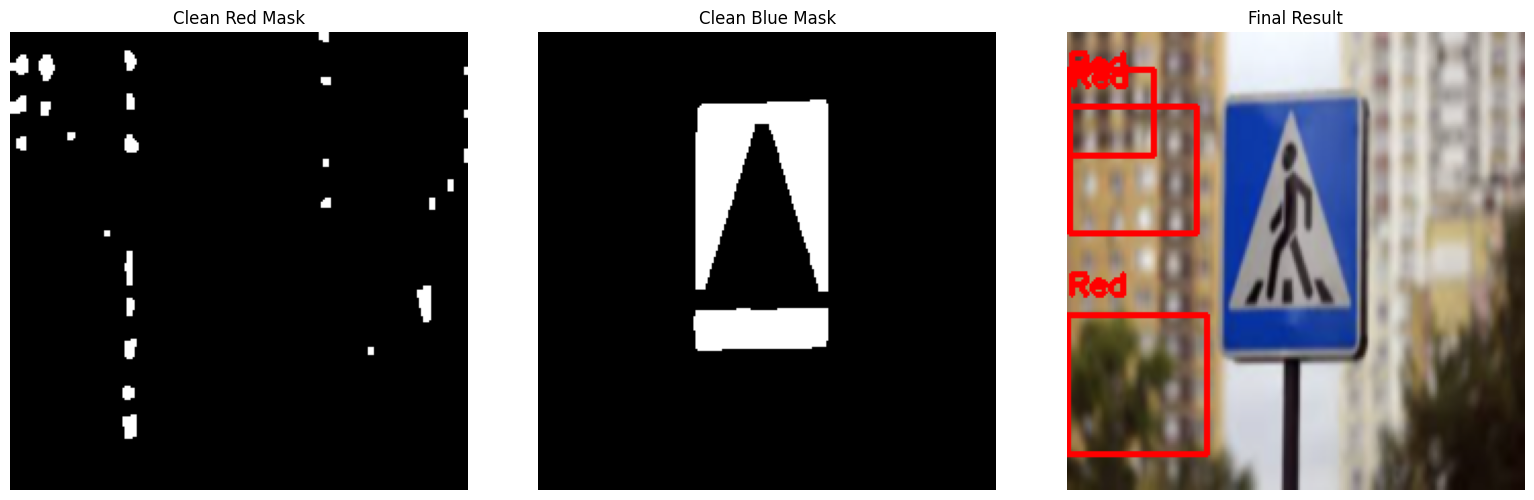

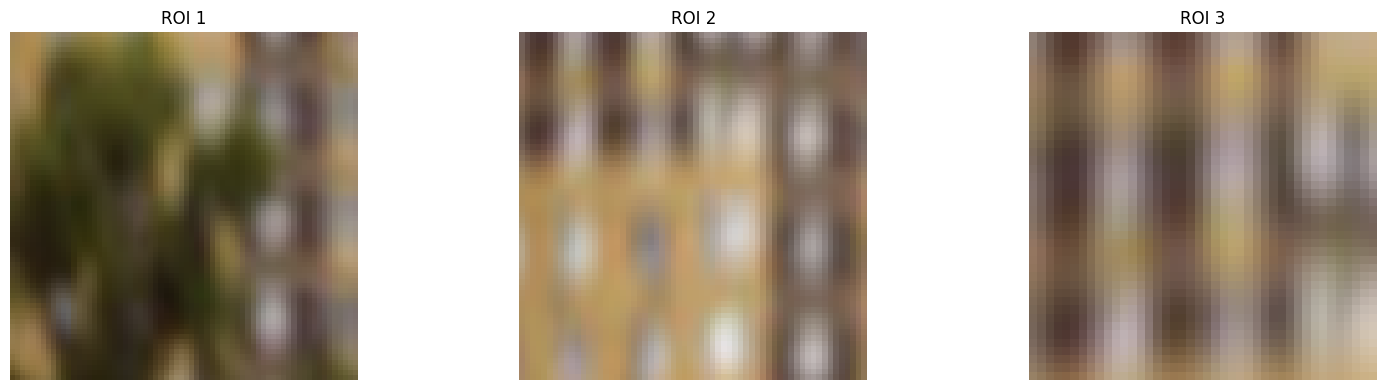

In [35]:
def calculate_iou(box_a, box_b):
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b

    left = max(ax, bx)
    top = max(ay, by)
    right = min(ax + aw, bx + bw)
    bottom = min(ay + ah, by + bh)

    if left >= right or top >= bottom:
        return 0.0

    intersection = (right - left) * (bottom - top)
    union = (aw * ah) + (bw * bh) - intersection
    return intersection / float(union)


def remove_overlapping_detections(detections, overlap_threshold=0.30):
    detections = sorted(detections, key=lambda item: item["score"], reverse=True)
    filtered = []

    for detection in detections:
        keep_detection = True
        for saved_detection in filtered:
            same_color = detection["color"] == saved_detection["color"]
            overlap = calculate_iou(detection["bbox"], saved_detection["bbox"])
            if same_color and overlap > overlap_threshold:
                keep_detection = False
                break

        if keep_detection:
            filtered.append(detection)

    return filtered


def detect_red_circles(image, red_mask):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray_image, (9, 9), 2)

    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=20,
        param1=100,
        param2=18,
        minRadius=8,
        maxRadius=80,
    )

    if circles is None:
        return []

    detections = []
    image_height, image_width = image.shape[:2]

    for center_x, center_y, radius in np.round(circles[0]).astype(int):
        x = max(center_x - radius, 0)
        y = max(center_y - radius, 0)
        w = min(2 * radius, image_width - x)
        h = min(2 * radius, image_height - y)

        if w < 12 or h < 12:
            continue

        ring_mask = np.zeros_like(red_mask)
        cv2.circle(ring_mask, (center_x, center_y), radius, 255, 2)
        overlap_mask = cv2.bitwise_and(red_mask, ring_mask)

        ring_pixels = cv2.countNonZero(ring_mask)
        red_pixels = cv2.countNonZero(overlap_mask)
        color_ratio = red_pixels / float(ring_pixels) if ring_pixels else 0.0

        if color_ratio < 0.08:
            continue

        detections.append(
            {
                "color": "Red",
                "bbox": (x, y, w, h),
                "area": float(np.pi * radius * radius),
                "fill_ratio": color_ratio,
                "color_ratio": color_ratio,
                "shape_name": "circle-like",
                "shape_sides": 8,
                "score": (np.pi * radius * radius) + (1200 * color_ratio),
            }
        )

    return detections


def detect_regions(image):
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    red_mask_1 = cv2.inRange(hsv_image, lower_red_1, upper_red_1)
    red_mask_2 = cv2.inRange(hsv_image, lower_red_2, upper_red_2)
    red_mask = cv2.bitwise_or(red_mask_1, red_mask_2)
    blue_mask = cv2.inRange(hsv_image, lower_blue, upper_blue)

    _, red_mask = clean_mask(red_mask, "Red")
    _, blue_mask = clean_mask(blue_mask, "Blue")

    red_contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blue_contours, _ = cv2.findContours(blue_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    detections = []

    for contour in red_contours:
        detection, _ = contour_to_detection(contour, red_mask, image, "Red", RED_SETTINGS)
        if detection is not None:
            detections.append(detection)

    for contour in blue_contours:
        detection, _ = contour_to_detection(contour, blue_mask, image, "Blue", BLUE_SETTINGS)
        if detection is not None:
            detections.append(detection)

    detections.extend(detect_red_circles(image, red_mask))
    detections = remove_overlapping_detections(detections)

    result_image = image.copy()
    rois = []

    for detection in detections:
        x, y, w, h = detection["bbox"]
        color = (0, 0, 255) if detection["color"] == "Red" else (255, 0, 0)

        cv2.rectangle(result_image, (x, y), (x + w, y + h), color, 2)
        cv2.putText(
            result_image,
            detection["color"],
            (x, max(y - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2,
        )

        roi = image[y : y + h, x : x + w]
        detection["roi"] = roi
        rois.append(roi)

    return {
        "red_mask": red_mask,
        "blue_mask": blue_mask,
        "combined_mask": cv2.bitwise_or(red_mask, blue_mask),
        "result_image": result_image,
        "rois": rois,
        "detections": detections,
    }


results = detect_regions(image_bgr)
print(f"Final detections: {len(results['detections'])}")
show_images(
    [
        ("Clean Red Mask", results["red_mask"], "gray"),
        ("Clean Blue Mask", results["blue_mask"], "gray"),
        ("Final Result", results["result_image"], None),
    ],
    figsize=(16, 5),
)

if results["rois"]:
    roi_items = []
    for index, roi in enumerate(results["rois"][:6], start=1):
        roi_items.append((f"ROI {index}", roi, None))
    show_images(roi_items, figsize=(16, 4))
else:
    print("No ROIs were extracted for this image.")

## Small Experiments

A notebook is useful because you can quickly test how parameter changes affect the result.

Below we compare:

- the default blue mask
- a stricter blue mask
- the default red mask
- a more sensitive red mask

This helps explain the trade-off between missing signs and creating false positives.

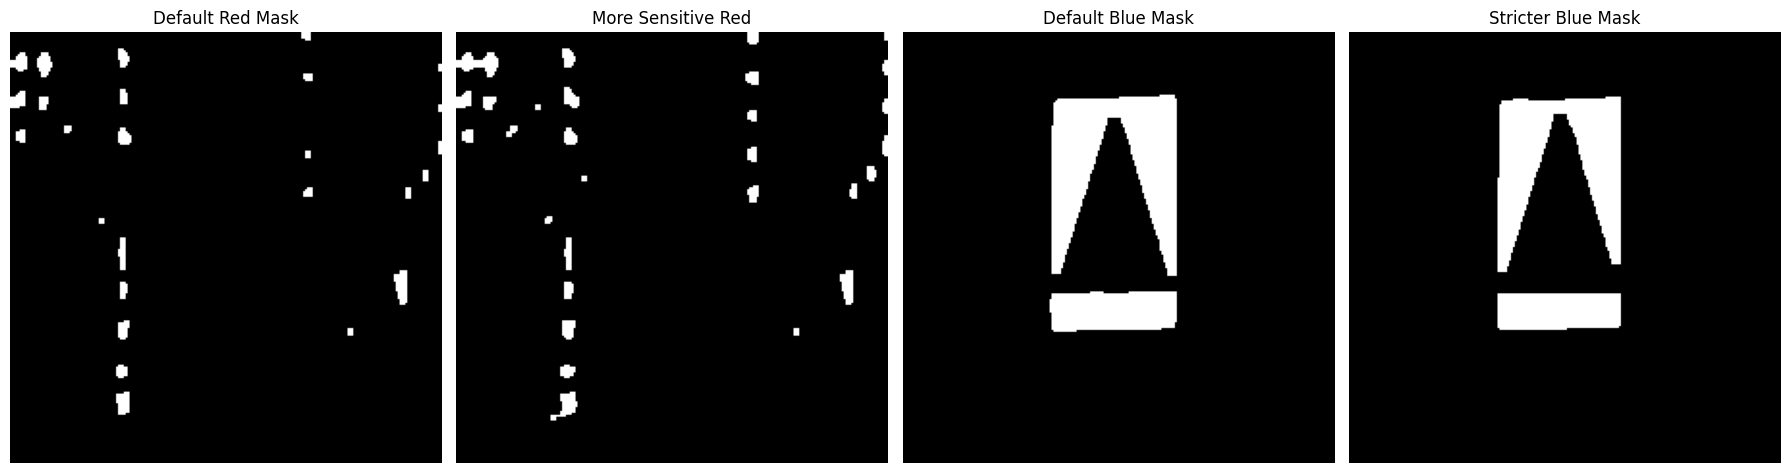

Tip: stricter blue settings reduce sky detections, while more sensitive red settings can recover faint red signs.


In [ ]:
# Stricter blue range: higher saturation requirement can reduce sky pixels.
experiment_lower_blue = np.array([102, 150, 50])
experiment_upper_blue = np.array([128, 255, 255])
stricter_blue_mask = cv2.inRange(image_hsv, experiment_lower_blue, experiment_upper_blue)
_, stricter_blue_mask = clean_mask(stricter_blue_mask, "Blue")

# More sensitive red range: lower saturation can recover faded red signs.
experiment_lower_red_1 = np.array([0, 35, 40])
experiment_upper_red_1 = np.array([10, 255, 255])
experiment_lower_red_2 = np.array([170, 35, 40])
experiment_upper_red_2 = np.array([180, 255, 255])

more_sensitive_red = cv2.bitwise_or(
    cv2.inRange(image_hsv, experiment_lower_red_1, experiment_upper_red_1),
    cv2.inRange(image_hsv, experiment_lower_red_2, experiment_upper_red_2),
)
_, more_sensitive_red = clean_mask(more_sensitive_red, "Red")

show_images(
    [
        ("Default Red Mask", clean_red_mask, "gray"),
        ("More Sensitive Red", more_sensitive_red, "gray"),
        ("Default Blue Mask", clean_blue_mask, "gray"),
        ("Stricter Blue Mask", stricter_blue_mask, "gray"),
    ],
    figsize=(18, 5),
)

print("Tip: stricter blue settings reduce sky detections, while more sensitive red settings can recover faint red signs.")

## Batch Preview on the Processed Dataset

Finally, it is helpful to test the detector on several processed images instead of only one sample.

This last cell runs the same pipeline on a few images from `data/processed` so you can quickly see how stable the detector is across the dataset.

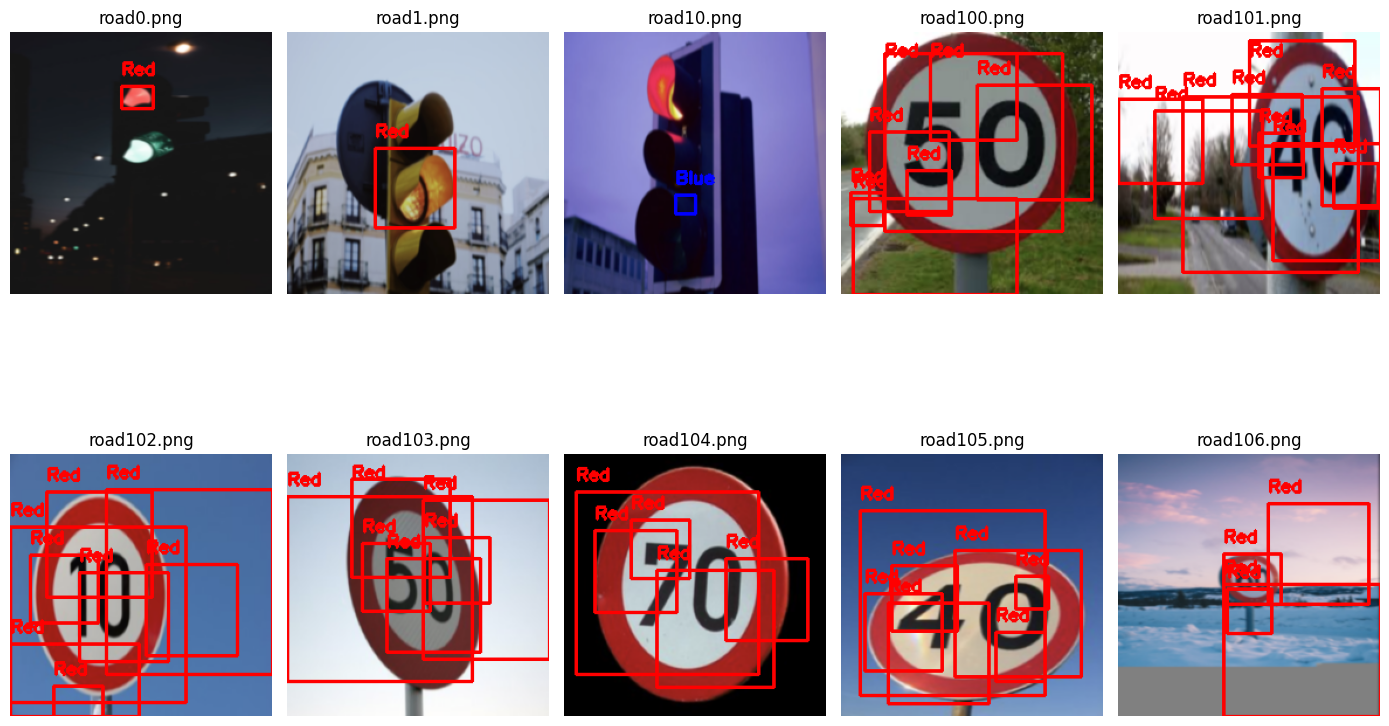

In [39]:
preview_paths = image_paths[:10]

if not preview_paths:
    print("No processed images are available for preview.")
else:
    plt.figure(figsize=(14, 10))

    for index, preview_path in enumerate(preview_paths, start=1):
        preview_image = cv2.imread(str(preview_path))
        preview_results = detect_regions(preview_image)

        plt.subplot(2, 5, index)
        plt.imshow(bgr_to_rgb(preview_results["result_image"]))
        plt.title(preview_path.name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()